# Data Analysis

This notebook analyses the model-ready PolitiSky24 datasets, including label distributions, annotation confidence, retrieved-context characteristics, candidate-name frequencies, evidence overlap across splits, and majority-class baselines.

## 1. Dataset Overview

General note: A more detailed analysis and interpretation of the findings presented in the notebook can be found in the paper itself.

We first inspect the basic structure of the two contextual datasets produced during preprocessing:

- the full LLM-labelled dataset, which is later divided into training and validation data,
- and the held-out human-annotated dataset used for final testing.

Each observation represents one `(UserId, TargetEntity)` pair, with separate observations for Trump and Harris.

We report the number of user-target pairs and unique users and verify the expected user-target structure. More detailed characteristics of the retrieved context posts are analysed separately below.

In [10]:
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq


DATA_DIR = Path("../data/preprocessed")

LLM_CONTEXT_PATH = DATA_DIR / "llm_user_target_contexts.parquet"
HUMAN_CONTEXT_PATH = DATA_DIR / "human_user_target_contexts.parquet"


overview_columns = [
    "UserId",
    "TargetEntity",
    "StanceLabel",
]

llm_df = pq.read_table(
    LLM_CONTEXT_PATH,
    columns=overview_columns
).to_pandas()

human_df = pq.read_table(
    HUMAN_CONTEXT_PATH,
    columns=overview_columns
).to_pandas()

In [11]:
overview = pd.DataFrame({
    "Dataset": [
        "LLM-labelled",
        "Human-annotated",
    ],
    "User-target pairs": [
        len(llm_df),
        len(human_df),
    ],
    "Unique users": [
        llm_df["UserId"].nunique(),
        human_df["UserId"].nunique(),
    ],
})

display(
    overview.style
    .hide(axis="index")
)

Dataset,User-target pairs,Unique users
LLM-labelled,16044,8022
Human-annotated,890,445


In [12]:
# Structural sanity checks
datasets = {
    "LLM-labelled": llm_df,
    "Human-annotated": human_df,
}

for name, df in datasets.items():

    # Each user-target pair should occur exactly once
    assert not df.duplicated(
        subset=["UserId", "TargetEntity"]
    ).any()

    # Only the two expected targets should occur
    assert set(df["TargetEntity"].unique()) == {
        "Trump",
        "Harris",
    }

    # Each user should have one row for each target
    rows_per_user = df.groupby("UserId").size()

    assert (rows_per_user == 2).all()

    print(
        f"{name}: "
        f"{len(df):,} user-target pairs, "
        f"{df['UserId'].nunique():,} users"
    )

print("\nAll structural checks passed.")

LLM-labelled: 16,044 user-target pairs, 8,022 users
Human-annotated: 890 user-target pairs, 445 users

All structural checks passed.


---
## 2. Label Distributions & Split Quality

We examine the distribution of stance labels across targets and datasets and verify whether the user-level train/validation split preserves the label structure of the full LLM-labelled dataset.

Because stance distributions differ substantially between Trump and Harris, labels are analysed separately for each target. We additionally inspect the joint Trump/Harris stance combinations at the user level as a stricter split-quality check.

The human-annotated test set is shown for comparison but is not used to assess the quality of the train/validation split.

In [13]:
# Paths to the final model-ready datasets created during preprocessing
TRAIN_PATH = DATA_DIR / "train.parquet"
VALIDATION_PATH = DATA_DIR / "validation.parquet"
HUMAN_TEST_PATH = DATA_DIR / "human_test.parquet"

# Only these columns are required for analysing class distributions
analysis_columns = [
    "UserId",
    "TargetEntity",
    "StanceLabel",
]

train_df = pq.read_table(
    TRAIN_PATH,
    columns=analysis_columns
).to_pandas()

validation_df = pq.read_table(
    VALIDATION_PATH,
    columns=analysis_columns
).to_pandas()

human_test_df = pq.read_table(
    HUMAN_TEST_PATH,
    columns=analysis_columns
).to_pandas()

# Use a fixed class order so all datasets are directly comparable
label_order = ["Against", "Neither", "Favor"]

distribution_datasets = {
    "Full LLM": llm_df,
    "Train": train_df,
    "Validation": validation_df,
    "Human test": human_test_df,
}

comparison_tables = []

for name, df in distribution_datasets.items():

    # Calculate the percentage of each stance label separately for Trump and Harris
    target_distribution = pd.crosstab(
        df["TargetEntity"],
        df["StanceLabel"],
        normalize="index"
    ).mul(100)

    # Ensure both targets and all three labels are always shown
    target_distribution = target_distribution.reindex(
        index=["Trump", "Harris"],
        columns=label_order,
        fill_value=0
    )

    target_distribution["Dataset"] = name

    comparison_tables.append(
        target_distribution.reset_index()
    )

# Combine all distributions into one comparison table
target_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

target_comparison = target_comparison[
    ["Dataset", "TargetEntity", "Against", "Neither", "Favor"]
]

target_comparison.columns.name = None

display(
    target_comparison.style
    .format({
        "Against": "{:.1f}%",
        "Neither": "{:.1f}%",
        "Favor": "{:.1f}%",
    })
    .hide(axis="index")
)

Dataset,TargetEntity,Against,Neither,Favor
Full LLM,Trump,84.3%,11.4%,4.3%
Full LLM,Harris,13.4%,52.6%,34.0%
Train,Trump,84.1%,11.6%,4.3%
Train,Harris,13.4%,53.0%,33.6%
Validation,Trump,85.0%,10.7%,4.4%
Validation,Harris,13.3%,51.3%,35.5%
Human test,Trump,87.6%,8.8%,3.6%
Human test,Harris,11.2%,39.6%,49.2%


The stance distributions differ strongly between Trump and Harris, while the train and validation distributions remain highly consistent. The human test set shows a noticeably higher proportion of Favor labels for Harris (49.2%) than the LLM-labelled data (34.0%).

In [14]:
def get_joint_label_distribution(df):
    # Reshape the two target-specific observations into one row per user
    user_labels = df.pivot(
        index="UserId",
        columns="TargetEntity",
        values="StanceLabel"
    )

    # Combine the Trump and Harris labels into one user-level category
    joint_labels = (
        "Trump=" + user_labels["Trump"]
        + " | Harris=" + user_labels["Harris"]
    )

    return (
        joint_labels
        .value_counts(normalize=True)
        .mul(100)
    )


# Compare the joint user-level distributions across the full data and both splits
joint_comparison = pd.concat(
    {
        "Full LLM": get_joint_label_distribution(llm_df),
        "Train": get_joint_label_distribution(train_df),
        "Validation": get_joint_label_distribution(validation_df),
    },
    axis=1
).fillna(0)

# Show the most common combinations first
joint_comparison = joint_comparison.sort_values(
    "Full LLM",
    ascending=False
)

display(
    joint_comparison.style
    .format("{:.1f}%")
)

,Full LLM,Train,Validation
Trump=Against | Harris=Neither,41.0%,41.2%,40.6%
Trump=Against | Harris=Favor,32.4%,32.0%,34.1%
Trump=Against | Harris=Against,10.8%,10.9%,10.3%
Trump=Neither | Harris=Neither,9.5%,9.7%,8.6%
Trump=Favor | Harris=Neither,2.1%,2.1%,2.1%
Trump=Favor | Harris=Against,1.8%,1.7%,1.9%
Trump=Neither | Harris=Favor,1.2%,1.2%,1.1%
Trump=Neither | Harris=Against,0.8%,0.7%,1.0%
Trump=Favor | Harris=Favor,0.4%,0.4%,0.3%


The joint Trump/Harris stance combinations are highly consistent across the full LLM dataset, training set, and validation set, indicating that the user-level split preserves the overall label structure well.

---
## 3. LLM Annotation Confidence

The training and validation labels were generated automatically by an LLM and are accompanied by a confidence score.

We therefore examine whether the available confidence scores indicate predominantly high or low annotation confidence. Because confidence scores are not available for every observation, missing values are reported explicitly and excluded from the confidence statistics.

The confidence score reflects the annotating model's own certainty and should not be interpreted as an independent measure of label correctness.

We first inspect overall confidence and missingness and then compare confidence across stance labels and target entities.

Total annotations,Available confidence,Missing confidence,Missing confidence (%)
"16,044","11,083","4,961",30.9%


Mean,Median,25th percentile,75th percentile,≥ 0.90,≥ 0.80,< 0.70,< 0.60
0.92,0.95,0.90,0.95,87.1%,96.4%,0.7%,0.1%


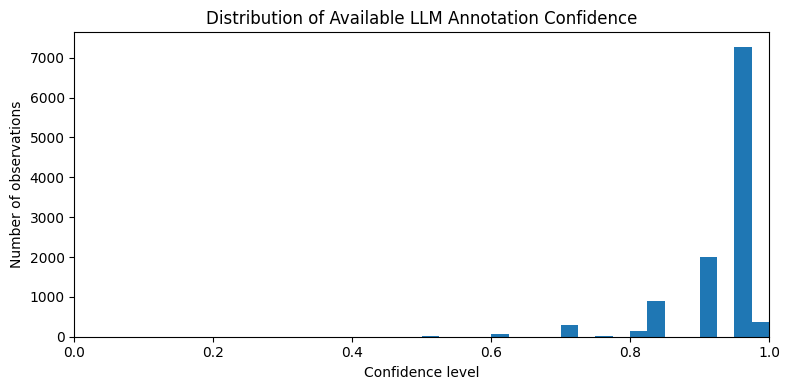

In [15]:
import matplotlib.pyplot as plt


# Load the confidence information retained in the rich LLM dataset
confidence_columns = [
    "TargetEntity",
    "StanceLabel",
    "ConfidenceLevel",
]

confidence_df = pq.read_table(
    LLM_CONTEXT_PATH,
    columns=confidence_columns
).to_pandas()


# Separate available confidence scores from missing values
confidence = confidence_df["ConfidenceLevel"].dropna()

assert confidence.between(0, 1).all()


# Report confidence-score availability
confidence_availability = pd.DataFrame({
    "Total annotations": [
        len(confidence_df)
    ],
    "Available confidence": [
        confidence_df["ConfidenceLevel"].notna().sum()
    ],
    "Missing confidence": [
        confidence_df["ConfidenceLevel"].isna().sum()
    ],
    "Missing confidence (%)": [
        confidence_df["ConfidenceLevel"].isna().mean() * 100
    ],
})

display(
    confidence_availability.style
    .format({
        "Total annotations": "{:,.0f}",
        "Available confidence": "{:,.0f}",
        "Missing confidence": "{:,.0f}",
        "Missing confidence (%)": "{:.1f}%",
    })
    .hide(axis="index")
)


# Round only for threshold comparisons to avoid floating-point issues
confidence_for_thresholds = confidence.round(2)

confidence_summary = pd.DataFrame({
    "Mean": [
        confidence.mean()
    ],
    "Median": [
        confidence.median()
    ],
    "25th percentile": [
        confidence.quantile(0.25)
    ],
    "75th percentile": [
        confidence.quantile(0.75)
    ],
    "≥ 0.90": [
        (confidence_for_thresholds >= 0.90).mean() * 100
    ],
    "≥ 0.80": [
        (confidence_for_thresholds >= 0.80).mean() * 100
    ],
    "< 0.70": [
        (confidence_for_thresholds < 0.70).mean() * 100
    ],
    "< 0.60": [
        (confidence_for_thresholds < 0.60).mean() * 100
    ],
})

display(
    confidence_summary.style
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "25th percentile": "{:.2f}",
        "75th percentile": "{:.2f}",
        "≥ 0.90": "{:.1f}%",
        "≥ 0.80": "{:.1f}%",
        "< 0.70": "{:.1f}%",
        "< 0.60": "{:.1f}%",
    })
    .hide(axis="index")
)


# Visualise the distribution of available LLM annotation confidence scores
plt.figure(figsize=(8, 4))

plt.hist(
    confidence,
    bins=20,
)

plt.xlabel("Confidence level")
plt.ylabel("Number of observations")
plt.title("Distribution of Available LLM Annotation Confidence")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
# Compare annotation confidence and availability across stance labels
confidence_by_stance = (
    confidence_df
    .groupby("StanceLabel")["ConfidenceLevel"]
    .agg(
        Mean="mean",
        Median="median",
        Available="count",
        Total="size",
    )
)

confidence_by_stance["Missing"] = (
    confidence_by_stance["Total"]
    - confidence_by_stance["Available"]
)

confidence_by_stance["Missing (%)"] = (
    confidence_by_stance["Missing"]
    / confidence_by_stance["Total"]
    * 100
)

confidence_by_stance = confidence_by_stance[
    [
        "Mean",
        "Median",
        "Available",
        "Missing",
        "Missing (%)",
        "Total",
    ]
]


# Compare annotation confidence and availability across target entities
confidence_by_target = (
    confidence_df
    .groupby("TargetEntity")["ConfidenceLevel"]
    .agg(
        Mean="mean",
        Median="median",
        Available="count",
        Total="size",
    )
)

confidence_by_target["Missing"] = (
    confidence_by_target["Total"]
    - confidence_by_target["Available"]
)

confidence_by_target["Missing (%)"] = (
    confidence_by_target["Missing"]
    / confidence_by_target["Total"]
    * 100
)

confidence_by_target = confidence_by_target[
    [
        "Mean",
        "Median",
        "Available",
        "Missing",
        "Missing (%)",
        "Total",
    ]
]


display(
    confidence_by_stance.style.format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Available": "{:,.0f}",
        "Missing": "{:,.0f}",
        "Missing (%)": "{:.1f}%",
        "Total": "{:,.0f}",
    })
)

display(
    confidence_by_target.style.format({
        "Mean": "{:.2f}",
        "Median": "{:.2f}",
        "Available": "{:,.0f}",
        "Missing": "{:,.0f}",
        "Missing (%)": "{:.1f}%",
        "Total": "{:,.0f}",
    })
)

,Mean,Median,Available,Missing,Missing (%),Total
StanceLabel,,,,,,
Against,0.93,0.95,"7,817",15,0.2%,"7,832"
Favor,0.91,0.95,"3,065",6,0.2%,"3,071"
Neither,0.68,0.70,201,"4,940",96.1%,"5,141"


,Mean,Median,Available,Missing,Missing (%),Total
TargetEntity,,,,,,
Harris,0.90,0.90,"3,897","4,125",51.4%,"8,022"
Trump,0.93,0.95,"7,186",836,10.4%,"8,022"


Among annotations with an available confidence score, confidence is generally high, with a median of 0.95 and 96.4% of scores at or above 0.80. However, confidence availability is strongly label-dependent: scores are available for nearly all Favor and Against annotations, but missing for 96.1% of Neither annotations. The confidence distribution is therefore not representative of the complete LLM-labelled dataset and is reported only as a descriptive property of annotations for which confidence was provided.

---
## 4. Retrieved Context Characteristics

The preprocessing pipeline reconstructs up to ten retrieved context posts for each user-target pair and orders uniquely identifiable posts from newest to oldest. It also records cases where an exact post timestamp cannot be recovered due to duplicate content in a user's posting history.

Since these properties are already validated during preprocessing, we only briefly describe the resulting context data here.

In particular, we examine how many context posts are available per observation, which determines the coverage of the later experiments using \(k = 1, 2, 5, 7, 10\) posts, and summarize the remaining timestamp ambiguity.

Dataset,Mean,Median,Min,Max,k ≥ 1,k ≥ 2,k ≥ 5,k ≥ 7,k ≥ 10
LLM-labelled,7.48,8.0,1,10,100.0%,99.6%,98.8%,81.1%,3.6%
Human-annotated,7.67,8.0,2,10,100.0%,100.0%,99.8%,85.5%,4.4%


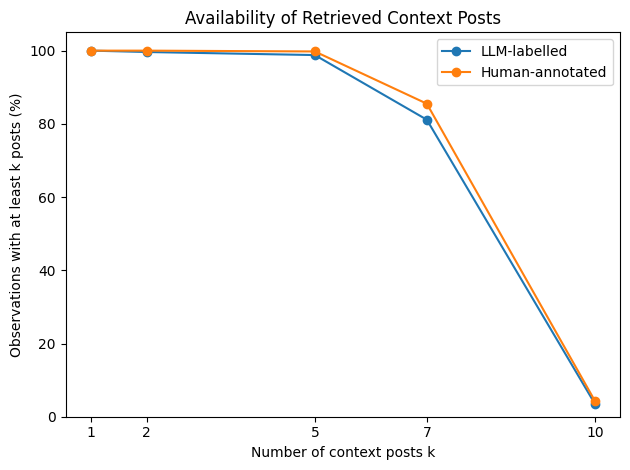

In [17]:

# Load the context-count metadata produced during preprocessing
context_columns = [
    "NumContextPosts",
    "NumAmbiguousTimestamps",
]

llm_context_stats = pq.read_table(
    LLM_CONTEXT_PATH,
    columns=context_columns
).to_pandas()

human_context_stats = pq.read_table(
    HUMAN_CONTEXT_PATH,
    columns=context_columns
).to_pandas()

context_datasets = {
    "LLM-labelled": llm_context_stats,
    "Human-annotated": human_context_stats,
}

# Summarise how many retrieved context posts are available per user-target pair
context_summary = []

for name, df in context_datasets.items():

    num_posts = df["NumContextPosts"]

    context_summary.append({
        "Dataset": name,
        "Mean": num_posts.mean(),
        "Median": num_posts.median(),
        "Min": num_posts.min(),
        "Max": num_posts.max(),
        "k ≥ 1": (num_posts >= 1).mean() * 100,
        "k ≥ 2": (num_posts >= 2).mean() * 100,
        "k ≥ 5": (num_posts >= 5).mean() * 100,
        "k ≥ 7": (num_posts >= 7).mean() * 100,
        "k ≥ 10": (num_posts >= 10).mean() * 100,
    })

context_summary = pd.DataFrame(context_summary)

display(
    context_summary.style
    .format({
        "Mean": "{:.2f}",
        "Median": "{:.1f}",
        "Min": "{:.0f}",
        "Max": "{:.0f}",
        "k ≥ 1": "{:.1f}%",
        "k ≥ 2": "{:.1f}%",
        "k ≥ 5": "{:.1f}%",
        "k ≥ 7": "{:.1f}%",
        "k ≥ 10": "{:.1f}%",
    })
    .hide(axis="index")
)

k_values = [1, 2, 5, 7, 10]

for _, row in context_summary.iterrows():

    percentages = [
        row[f"k ≥ {k}"]
        for k in k_values
    ]

    plt.plot(
        k_values,
        percentages,
        marker="o",
        label=row["Dataset"],
    )

plt.xlabel("Number of context posts k")
plt.ylabel("Observations with at least k posts (%)")
plt.title("Availability of Retrieved Context Posts")
plt.xticks(k_values)
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

Most observations contain sufficient context for experiments up to \(k=7\), whereas only 3.6% of LLM-labelled and 4.4% of human-annotated observations contain all ten retrieved posts. This is an important constraint to consider when constructing the later context-size analysis.

In [18]:
# Summarise how often timestamps could not be uniquely recovered
ambiguity_summary = []

for name, df in context_datasets.items():

    total_posts = df["NumContextPosts"].sum()
    ambiguous_posts = df["NumAmbiguousTimestamps"].sum()

    rows_with_ambiguity = (
        df["NumAmbiguousTimestamps"] > 0
    ).sum()

    ambiguity_summary.append({
        "Dataset": name,
        "Context posts": total_posts,
        "Ambiguous posts": ambiguous_posts,
        "Ambiguous posts (%)": ambiguous_posts / total_posts * 100,
        "Rows with ambiguity": rows_with_ambiguity,
        "Rows with ambiguity (%)": rows_with_ambiguity / len(df) * 100,
    })

ambiguity_summary = pd.DataFrame(ambiguity_summary)

display(
    ambiguity_summary.style
    .format({
        "Context posts": "{:,.0f}",
        "Ambiguous posts": "{:,.0f}",
        "Ambiguous posts (%)": "{:.2f}%",
        "Rows with ambiguity": "{:,.0f}",
        "Rows with ambiguity (%)": "{:.2f}%",
    })
    .hide(axis="index")
)

Dataset,Context posts,Ambiguous posts,Ambiguous posts (%),Rows with ambiguity,Rows with ambiguity (%)
LLM-labelled,"119,954","1,565",1.30%,"1,032",6.43%
Human-annotated,"6,829",57,0.83%,44,4.94%


---
## 5. Candidate-Name Frequencies in Retrieved Context

We examine how often the two political candidates are explicitly mentioned in the retrieved context posts.

Unlike the previous analysis of complete user posting histories, we focus only on the retrieved evidence that is actually available to the stance-classification models.

For each user-target pair, we distinguish between mentions of the target candidate and mentions of the opposing candidate. This provides an indication of how strongly the retrieved evidence contains explicit lexical cues that could potentially be exploited as shortcuts by the models.

Candidate surnames are matched as complete words and case-insensitively. A context post is counted at most once per candidate.

In [19]:
import re


# Load the target and retrieved context posts
candidate_columns = [
    "TargetEntity",
    "ContextPosts",
]

llm_candidate_df = pq.read_table(
    LLM_CONTEXT_PATH,
    columns=candidate_columns
).to_pandas()

human_candidate_df = pq.read_table(
    HUMAN_CONTEXT_PATH,
    columns=candidate_columns
).to_pandas()

candidate_datasets = {
    "LLM-labelled": llm_candidate_df,
    "Human-annotated": human_candidate_df,
}


# Match candidate surnames as complete words and case-insensitively
candidate_patterns = {
    "Trump": re.compile(r"\btrump\b", re.IGNORECASE),
    "Harris": re.compile(r"\bharris\b", re.IGNORECASE),
}

In [20]:
def count_candidate_mentions(df):

    rows = []

    for _, row in df.iterrows():

        target = row["TargetEntity"]

        # Determine which candidate is the opposing candidate for this row
        other_candidate = (
            "Harris" if target == "Trump" else "Trump"
        )

        target_mentions = 0
        other_mentions = 0

        for post in row["ContextPosts"]:

            content = post["Content"] or ""

            # Count posts rather than individual word occurrences
            if candidate_patterns[target].search(content):
                target_mentions += 1

            if candidate_patterns[other_candidate].search(content):
                other_mentions += 1

        rows.append({
            "TargetEntity": target,
            "NumContextPosts": len(row["ContextPosts"]),
            "TargetMentionPosts": target_mentions,
            "OtherCandidateMentionPosts": other_mentions,
        })

    return pd.DataFrame(rows)


candidate_results = {
    name: count_candidate_mentions(df)
    for name, df in candidate_datasets.items()
}

In [21]:
candidate_summary = []

for name, df in candidate_results.items():

    for target in ["Trump", "Harris"]:

        target_df = df[
            df["TargetEntity"] == target
        ]

        # Check whether at least one retrieved post contains each type of cue
        rows_with_target = (
            target_df["TargetMentionPosts"] > 0
        ).mean() * 100

        rows_with_other = (
            target_df["OtherCandidateMentionPosts"] > 0
        ).mean() * 100

        # Check how often neither candidate surname appears anywhere in the context
        rows_with_neither = (
            (target_df["TargetMentionPosts"] == 0)
            & (target_df["OtherCandidateMentionPosts"] == 0)
        ).mean() * 100

        # Measure how much of the retrieved evidence explicitly mentions the target
        target_post_percentage = (
            target_df["TargetMentionPosts"].sum()
            / target_df["NumContextPosts"].sum()
            * 100
        )

        other_post_percentage = (
            target_df["OtherCandidateMentionPosts"].sum()
            / target_df["NumContextPosts"].sum()
            * 100
        )

        candidate_summary.append({
            "Dataset": name,
            "TargetEntity": target,
            "Rows with target mention": rows_with_target,
            "Rows with other candidate mention": rows_with_other,
            "Rows with neither": rows_with_neither,
            "Context posts mentioning target": target_post_percentage,
            "Context posts mentioning other candidate": other_post_percentage,
        })


candidate_summary = pd.DataFrame(candidate_summary)

display(
    candidate_summary.style
    .format({
        "Rows with target mention": "{:.1f}%",
        "Rows with other candidate mention": "{:.1f}%",
        "Rows with neither": "{:.1f}%",
        "Context posts mentioning target": "{:.1f}%",
        "Context posts mentioning other candidate": "{:.1f}%",
    })
    .hide(axis="index")
)

Dataset,TargetEntity,Rows with target mention,Rows with other candidate mention,Rows with neither,Context posts mentioning target,Context posts mentioning other candidate
LLM-labelled,Trump,95.3%,11.6%,4.5%,60.9%,1.9%
LLM-labelled,Harris,54.1%,67.0%,16.3%,18.4%,16.0%
Human-annotated,Trump,98.2%,13.3%,1.8%,61.1%,2.3%
Human-annotated,Harris,67.4%,64.3%,13.3%,23.9%,13.7%


Explicit candidate cues are common but highly target-dependent: Trump is mentioned in 95.3% of Trump-target contexts, while Harris is mentioned in only 54.1% of Harris-target contexts in the LLM-labelled data. This will become relevant when masking candidate names in the later experiments.

---
## 6. Evidence Overlap Across Splits

The preprocessing pipeline ensures that users do not overlap between training, validation, and human test data. However, different users may still share the same political content, for example through reposts.

We therefore examine whether exact context-post contents appearing in the validation or human test set also occur in the training set.

We report overlap both at the context-post level and at the user-target level. Shared content is not removed automatically, since repeated or reposted political content represents genuine user behaviour and may itself contribute to shortcut learning. The analysis is therefore intended to quantify this overlap rather than treat it as preprocessing leakage.

In [22]:
# Load the actual retrieved evidence used in each model split
overlap_columns = [
    "UserId",
    "TargetEntity",
    "ContextPosts",
]

train_overlap_df = pq.read_table(
    TRAIN_PATH,
    columns=overlap_columns
).to_pandas()

validation_overlap_df = pq.read_table(
    VALIDATION_PATH,
    columns=overlap_columns
).to_pandas()

human_test_overlap_df = pq.read_table(
    HUMAN_TEST_PATH,
    columns=overlap_columns
).to_pandas()

def extract_contents(df):
    contents = []

    for posts in df["ContextPosts"]:
        for post in posts:
            content = post["Content"]

            if content is not None:
                contents.append(content)

    return contents


# Flatten all retrieved context posts for each split
train_contents = extract_contents(train_overlap_df)
validation_contents = extract_contents(validation_overlap_df)
human_test_contents = extract_contents(human_test_overlap_df)

# Sets are used to check whether an exact content string occurred in training
train_content_set = set(train_contents)
validation_content_set = set(validation_contents)
human_test_content_set = set(human_test_contents)

In [23]:
def calculate_overlap(df, contents, content_set, train_content_set):

    # Find unique content strings that also occur in the training set
    overlapping_unique = (
        content_set & train_content_set
    )

    # Count every context-post occurrence whose exact content appeared in training
    overlapping_occurrences = sum(
        content in train_content_set
        for content in contents
    )

    # Check how many user-target rows contain at least one overlapping post
    rows_with_overlap = 0

    for posts in df["ContextPosts"]:

        has_overlap = any(
            post["Content"] in train_content_set
            for post in posts
            if post["Content"] is not None
        )

        if has_overlap:
            rows_with_overlap += 1

    return {
        "Unique contents": len(content_set),
        "Unique overlap": len(overlapping_unique),
        "Unique overlap (%)": (
            len(overlapping_unique) / len(content_set) * 100
        ),
        "Context posts": len(contents),
        "Overlapping context posts": overlapping_occurrences,
        "Context-post overlap (%)": (
            overlapping_occurrences / len(contents) * 100
        ),
        "Rows with overlap": rows_with_overlap,
        "Rows with overlap (%)": (
            rows_with_overlap / len(df) * 100
        ),
    }

overlap_summary = []

for name, df, contents, content_set in [
    (
        "Validation",
        validation_overlap_df,
        validation_contents,
        validation_content_set,
    ),
    (
        "Human test",
        human_test_overlap_df,
        human_test_contents,
        human_test_content_set,
    ),
]:

    result = calculate_overlap(
        df,
        contents,
        content_set,
        train_content_set,
    )

    result["Dataset"] = name

    overlap_summary.append(result)


overlap_summary = pd.DataFrame(overlap_summary)

overlap_summary = overlap_summary[
    [
        "Dataset",
        "Unique contents",
        "Unique overlap",
        "Unique overlap (%)",
        "Context posts",
        "Overlapping context posts",
        "Context-post overlap (%)",
        "Rows with overlap",
        "Rows with overlap (%)",
    ]
]

display(
    overlap_summary.style
    .format({
        "Unique contents": "{:,.0f}",
        "Unique overlap": "{:,.0f}",
        "Unique overlap (%)": "{:.2f}%",
        "Context posts": "{:,.0f}",
        "Overlapping context posts": "{:,.0f}",
        "Context-post overlap (%)": "{:.2f}%",
        "Rows with overlap": "{:,.0f}",
        "Rows with overlap (%)": "{:.2f}%",
    })
    .hide(axis="index")
)

Dataset,Unique contents,Unique overlap,Unique overlap (%),Context posts,Overlapping context posts,Context-post overlap (%),Rows with overlap,Rows with overlap (%)
Validation,"15,915","3,330",20.92%,"23,925","8,096",33.84%,"2,351",73.24%
Human test,"4,924","1,445",29.35%,"6,829","2,702",39.57%,715,80.34%


Exact context-post overlap across users is substantial, with 33.84% of validation and 39.57% of human-test context-post occurrences having identical text in the training data. Therefore, evaluation measures generalization to unseen users, but not necessarily to entirely unseen evidence.

---
## 7. Majority Baselines

Finally, we establish simple majority-class baselines against which later models can be compared.

We consider two baselines:

- **Global majority baseline:** always predicts the most frequent stance label in the training set
- **Target-conditioned majority baseline:** predicts the most frequent training label separately for Trump and Harris

The target-conditioned baseline is particularly relevant because the stance distributions differ strongly between the two candidates.

Both baselines are derived exclusively from the training data and evaluated on the validation and human-test sets using accuracy and macro-F1.

In [24]:
# Determine the overall majority class from the training set
global_majority = train_df["StanceLabel"].mode()[0]

# Determine the majority class separately for each target
target_majorities = (
    train_df
    .groupby("TargetEntity")["StanceLabel"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

print("Global majority:", global_majority)
print("Target-conditioned majorities:", target_majorities)

Global majority: Against
Target-conditioned majorities: {'Harris': 'Neither', 'Trump': 'Against'}


In [25]:
import sys

# Add the project root so modules inside src can be imported
sys.path.append(str(Path("..").resolve()))

from src.utils import evaluate_predictions


baseline_results = []

for dataset_name, df in {
    "Validation": validation_df,
    "Human test": human_test_df,
}.items():

    # Predict the global training majority for every observation
    global_predictions = [global_majority] * len(df)

    global_scores = evaluate_predictions(
        df["StanceLabel"],
        global_predictions,
        labels=label_order,
    )

    baseline_results.append({
        "Dataset": dataset_name,
        "Baseline": "Global majority",
        **global_scores,
    })

    # Predict the corresponding training majority for Trump or Harris
    target_predictions = df["TargetEntity"].map(
        target_majorities
    )

    target_scores = evaluate_predictions(
        df["StanceLabel"],
        target_predictions,
        labels=label_order,
    )

    baseline_results.append({
        "Dataset": dataset_name,
        "Baseline": "Target-conditioned majority",
        **target_scores,
    })


baseline_results = pd.DataFrame(baseline_results)

# Convert evaluation scores to percentages for easier interpretation
baseline_results[["accuracy", "f1_macro"]] = (
    baseline_results[["accuracy", "f1_macro"]]
    .mul(100)
    .round(1)
)

# Rename metrics for presentation
baseline_results = baseline_results.rename(columns={
    "accuracy": "Accuracy",
    "f1_macro": "Macro-F1",
})

display(
    baseline_results.style
    .format({
        "Accuracy": "{:.1f}%",
        "Macro-F1": "{:.1f}%",
    })
    .hide(axis="index")
)

Dataset,Baseline,Accuracy,Macro-F1
Validation,Global majority,49.1%,22.0%
Validation,Target-conditioned majority,68.1%,49.7%
Human test,Global majority,49.4%,22.1%
Human test,Target-conditioned majority,63.6%,47.2%
